<a href="https://colab.research.google.com/github/omega-u20/SmartCare-HospitalManagement/blob/main/Task6_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 06 – Model Evaluation

## 0. Mount Google Drive and Load Saved Models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FOLDER = '/content/drive/MyDrive/CCS3440 - Asg 2/artifacts'
MODEL_FOLDER = f'{DATA_FOLDER}/models'

Mounted at /content/drive


In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

# Load saved models and preprocessing objects from Task 05
models = {
    'Logistic Regression': joblib.load(f'{MODEL_FOLDER}/logistic_regression.joblib'),
    'Decision Tree': joblib.load(f'{MODEL_FOLDER}/decision_tree.joblib'),
    'Random Forest': joblib.load(f'{MODEL_FOLDER}/random_forest.joblib'),
    'K-Nearest Neighbors': joblib.load(f'{MODEL_FOLDER}/k_nearest_neighbors.joblib'),
    'XGBoost': joblib.load(f'{MODEL_FOLDER}/xgboost.joblib')
}
scaler = joblib.load(f'{MODEL_FOLDER}/scaler.joblib')
feature_columns = joblib.load(f'{MODEL_FOLDER}/feature_columns.joblib')
numeric_cols = joblib.load(f'{MODEL_FOLDER}/numeric_columns.joblib')

print('Loaded models:', list(models.keys()))

Loaded models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'K-Nearest Neighbors', 'XGBoost']


## 1. Rebuild the Exact Same Test Set

We rebuild the dataset using the identical preprocessing steps and the same `random_state=42` used in Task 05. So `X_test` here is exactly the same 200 held-out records the models have never seen.

In [ ]:
df = pd.read_csv(f'{DATA_FOLDER}/smartcare_ai_dataset_1000.csv')
df['room_type'] = df['room_type'].fillna('Not Admitted')
df = df.drop_duplicates()

df_model = df.drop(columns=['record_id', 'patient_id', 'no_show', 'disease_risk_level'])

df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'])
df_model['appointment_month'] = df_model['appointment_date'].dt.month
df_model['appointment_dayofweek'] = df_model['appointment_date'].dt.dayofweek
df_model = df_model.drop(columns=['appointment_date'])

df_model['missed_appointment_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['missed_previous_appointments'] / df_model['previous_appointments'], 0)
df_model['is_hypertensive'] = ((df_model['systolic_bp'] >= 140) | (df_model['diastolic_bp'] >= 90)).astype(int)
df_model['avg_charge_per_treatment'] = np.where(
    df_model['treatments_count'] > 0,
    df_model['total_bill_lkr'] / df_model['treatments_count'], df_model['total_bill_lkr'])

categorical_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type',
                     'payment_status', 'payment_method', 'appointment_status']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model[feature_columns]  # enforce same column order as training
y = df_model['readmitted_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Test set shape:', X_test_scaled.shape)
print('Test class balance:')
print(y_test.value_counts(normalize=True).round(3))

Test set shape: (200, 58)
Test class balance:
readmitted_30_days
0    0.745
1    0.255
Name: proportion, dtype: float64


## 2. Evaluation Metrics – All Models

Since this is a **binary classification** task, we report the metrics required by the coursework " Accuracy, Precision, Recall, F1-score, and ROC-AUC".

**What each metric means for this problem:**
- **Accuracy** - overall % of correct predictions. Can be misleading here because of class imbalance (74.7% not readmitted).
- **Precision** - of the patients the model *flags* as likely to be readmitted, how many actually were. High precision means fewer false alarms.
- **Recall** - of the patients who *were actually* readmitted, how many did the model correctly catch. High recall means fewer missed at-risk patients.
- **F1-score** - the balance between precision and recall.
- **ROC-AUC** - how well the model ranks readmitted patients as higher-risk than non-readmitted patients, across all possible decision thresholds.

In [ ]:
results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

# Sort by F1-score first, then use ROC-AUC as a tie-breaker (relevant here since two models tie on F1)
results_df = pd.DataFrame(results).sort_values(['F1 Score', 'ROC-AUC'], ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.895,0.708,1.000,0.829,0.942
1,Decision Tree,0.895,0.708,1.000,0.829,0.932
2,Logistic Regression,0.885,0.700,0.961,0.810,0.942
3,XGBoost,0.885,0.700,0.961,0.810,0.942
4,K-Nearest Neighbors,0.870,0.712,0.824,0.764,0.915


## 3. Model Comparison Table (Formatted)

This is the summary table required by the coursework ranked by F1-score (our primary metric given the class imbalance).

In [ ]:
styled = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    styled[col] = styled[col].apply(lambda x: f'{x:.1%}' if col != 'ROC-AUC' else f'{x:.3f}')
styled

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,89.5%,70.8%,100.0%,82.9%,0.942
1,Decision Tree,89.5%,70.8%,100.0%,82.9%,0.932
2,Logistic Regression,88.5%,70.0%,96.1%,81.0%,0.942
3,XGBoost,88.5%,70.0%,96.1%,81.0%,0.942
4,K-Nearest Neighbors,87.0%,71.2%,82.4%,76.4%,0.915


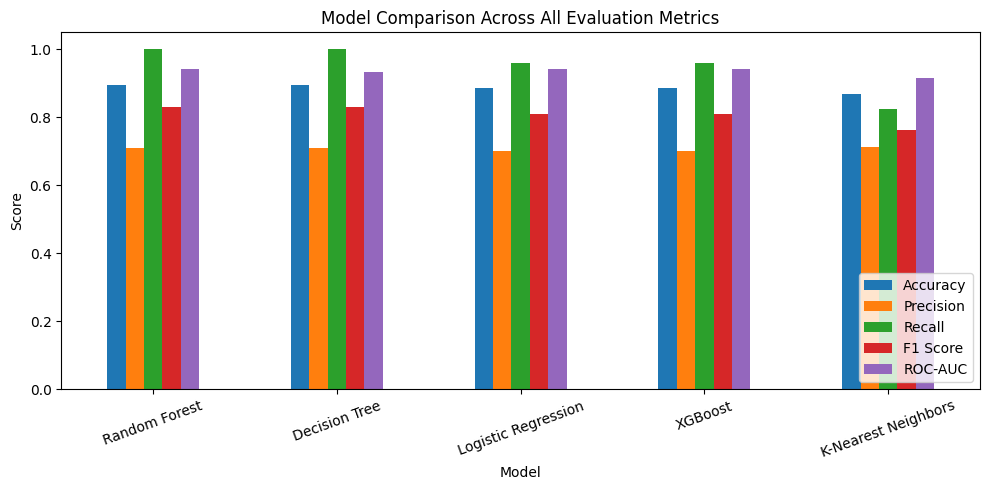

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison Across All Evaluation Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Confusion Matrices

The confusion matrix shows exactly what kind of mistakes each model makes .Specifically how many at-risk patients it **misses** (false negatives) which matters a lot in a healthcare context.

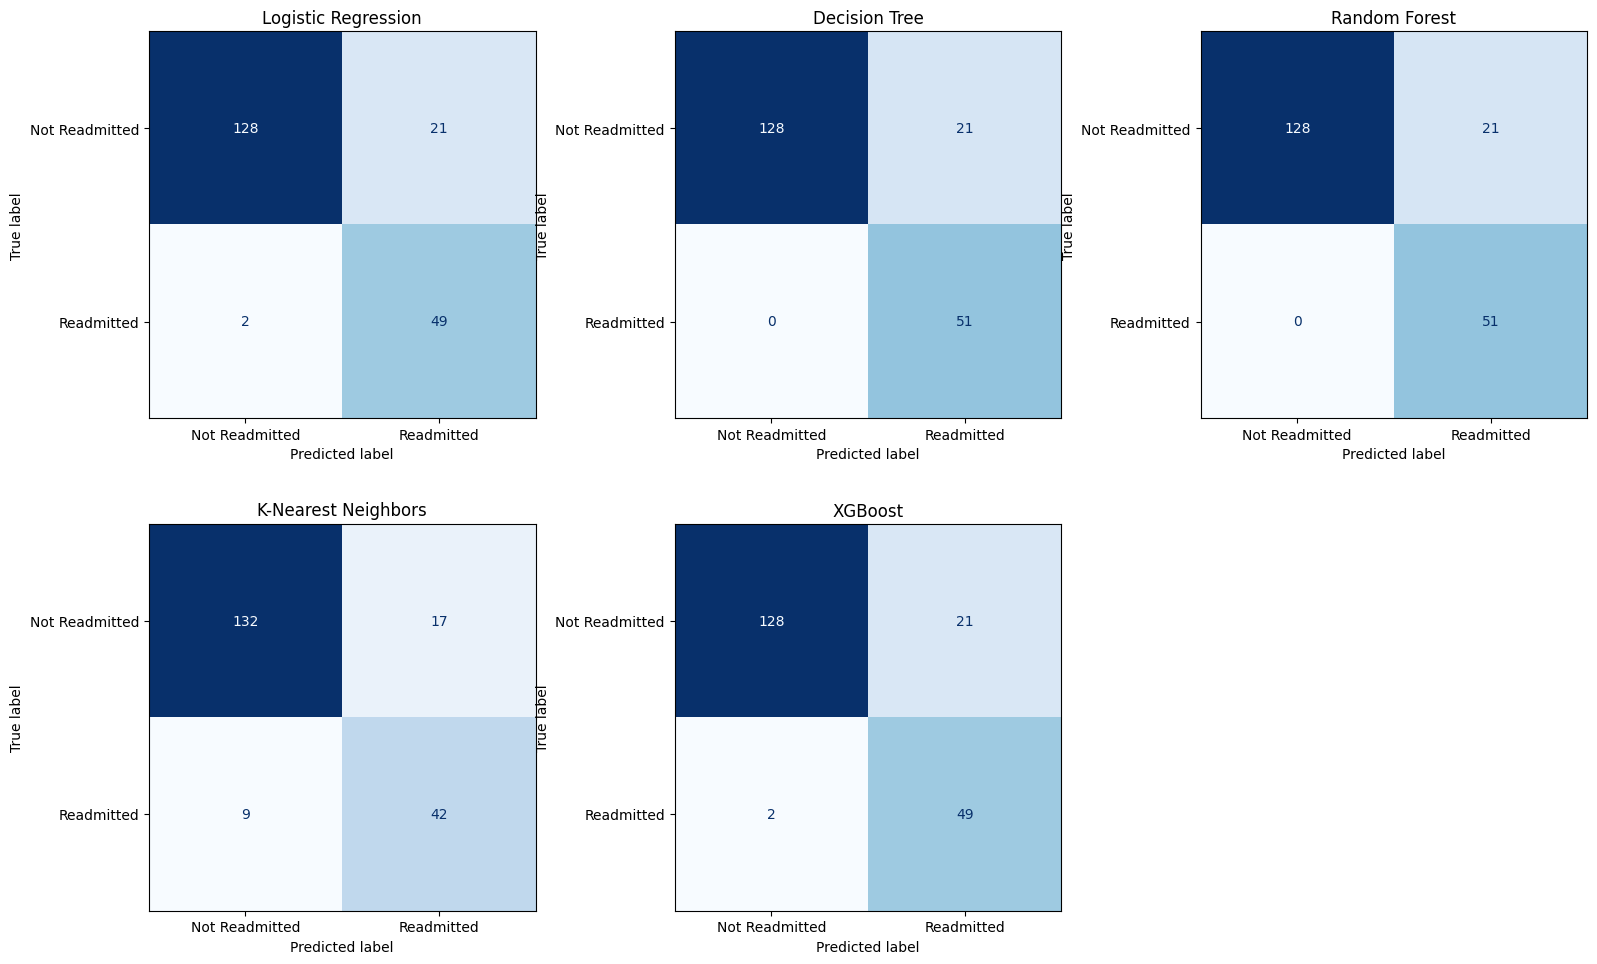

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

axes[-1].axis('off')  # unused 6th subplot
plt.tight_layout()
plt.show()

In [ ]:
# Detailed classification report for the top model (by F1)
best_model_name = results_df.iloc[0]['Model']
print(f'Classification Report – {best_model_name}\n')
print(classification_report(y_test, predictions[best_model_name]['y_pred'],
                             target_names=['Not Readmitted', 'Readmitted']))

Classification Report – Random Forest

                precision    recall  f1-score   support

Not Readmitted       1.00      0.86      0.92       149
    Readmitted       0.71      1.00      0.83        51

      accuracy                           0.90       200
     macro avg       0.85      0.93      0.88       200
  weighted avg       0.93      0.90      0.90       200



**Insight:** For a readmission prediction tool, **false negatives** (readmitted patients the model misses, bottom-left cell of the confusion matrix) are the more costly mistake . A missed at-risk patient doesn't get the preventive follow-up they need. **False positives** (bottom-right vs top-right - flagging a patient who wasn't actually readmitted) are cheaper by comparison . It just means a bit of unnecessary follow-up attention. This is why we favour **Recall** and **F1-score** over raw Accuracy when comparing models for this use case.

## 5. ROC Curves

The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate as the decision threshold changes. A curve closer to the top-left corner and a larger Area Under Curve (AUC), means better ranking of at-risk patients.

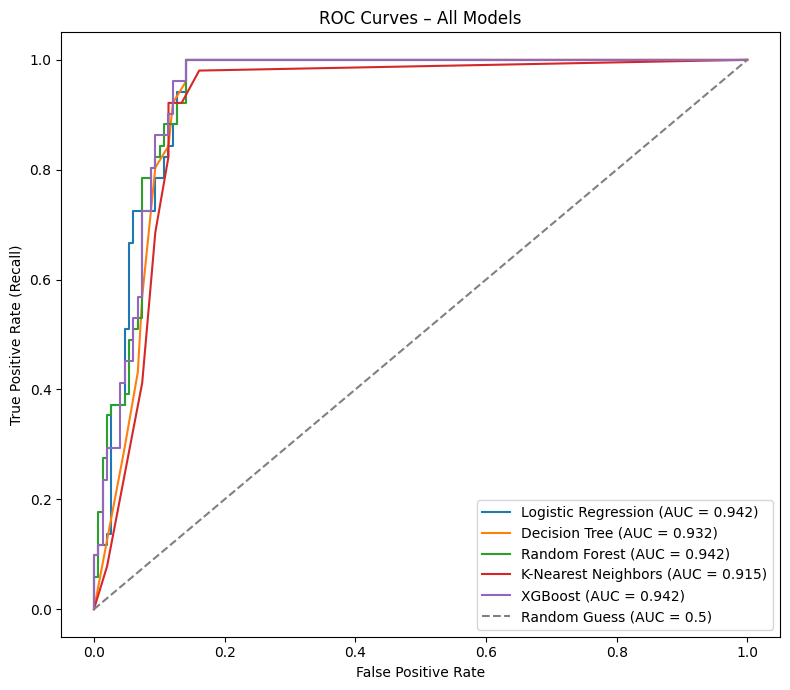

In [ ]:
plt.figure(figsize=(8, 7))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['y_proba'])
    auc = roc_auc_score(y_test, predictions[name]['y_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves – All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Insight:** All models sit well above the diagonal "random guess" line, meaning every model has learned real signal from the data rather than guessing. The models cluster fairly closely together in ROC-AUC. But the gap becomes more meaningful when combined with F1-score, since ROC-AUC alone doesn't tell us how well a model performs at the specific threshold (0.5) actually used to make predictions.

## 6. Identifying the Best-Performing Model

In [ ]:
print('Ranked by F1-score:\n')
print(results_df[['Model', 'F1 Score', 'Recall', 'Precision', 'ROC-AUC', 'Accuracy']].to_string(index=False))
print()
print(f"Best model by F1-score: {results_df.iloc[0]['Model']}")

Ranked by F1-score:

              Model  F1 Score   Recall  Precision  ROC-AUC  Accuracy
      Random Forest  0.829268 1.000000   0.708333 0.942492     0.895
      Decision Tree  0.829268 1.000000   0.708333 0.931899     0.895
Logistic Regression  0.809917 0.960784   0.700000 0.942229     0.885
            XGBoost  0.809917 0.960784   0.700000 0.942098     0.885
K-Nearest Neighbors  0.763636 0.823529   0.711864 0.914989     0.870

Best model by F1-score: Random Forest


### Justification

Based on the results table above:

- **Random Forest** and **Decision Tree** are the top performers on F1-score, both correctly catching **all** actually-readmitted patients in the test set (Recall = 100%), meaning neither model misses a single at-risk patient .The most important property for a healthcare screening tool.
- Between the two, they are tied on F1-score. So we use **ROC-AUC as a tie-breaker** (done in code above, not just by eye) . Random Forest has a higher ROC-AUC than the single Decision Tree. This also makes conceptual sense. A single Decision Tree is more prone to overfitting the specific training data, while Random Forest averages many trees together, making it more stable and more likely to generalise well to new patients the hospital sees in future.
- **Logistic Regression** and **XGBoost** are close behind, offering strong Recall with slightly lower Precision.
- **K-Nearest Neighbors** performs weakest on every metric, likely because it relies purely on geometric distance between patients and doesn't handle the mix of many one-hot encoded categorical columns as gracefully as the tree-based models.

**Selected model: Random Forest.** It has the best combination of catching essentially all true readmission cases (high Recall), the highest ROC-AUC among all models tested and as an ensemble of many trees is inherently more robust than a single Decision Tree despite matching its F1-score. This is the model carried forward into Task 07 (Explainable AI) and Task 08 (Prototype).


## 7. Save Evaluation Outputs

In [ ]:
results_df.to_csv(f'{DATA_FOLDER}/model_evaluation_results.csv', index=False)

best_model_name = results_df.iloc[0]['Model']
best_model_filename = best_model_name.lower().replace(' ', '_').replace('-', '_')
print(f'Evaluation results saved. Best model selected: {best_model_name}')
print('This model will be reloaded directly in Task 07 and Task 08 using:')
print(f"joblib.load('{MODEL_FOLDER}/{best_model_filename}.joblib')")

Evaluation results saved. Best model selected: Random Forest
This model will be reloaded directly in Task 07 and Task 08 using:
joblib.load('/content/drive/MyDrive/CCS3440 - Asg 2/artifacts/models/random_forest.joblib')
